In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jawadwali/weatherprediction/seattle-weather.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, accuracy_score


In [9]:
import pandas as pd

# Jo path aapne copy kiya hai usay yahan paste karein
path = '/kaggle/input/datasets/jawadwali/weatherprediction/seattle-weather.csv' 

In [10]:
X_reg = df[['temp_min']]
y_reg = df['temp_max']

In [11]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


In [13]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)
y_pred_lin = lin_model.predict(X_test_r)

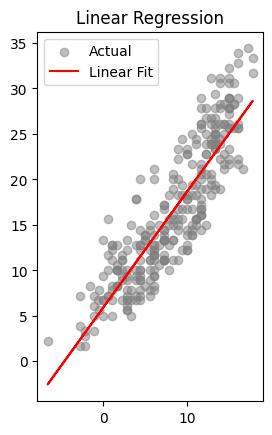

In [14]:
# Linear Plot
plt.subplot(1, 2, 1)
plt.scatter(X_test_r, y_test_r, color='gray', alpha=0.5, label='Actual')
plt.plot(X_test_r, y_pred_lin, color='red', label='Linear Fit')
plt.title('Linear Regression')
plt.legend()

In [15]:
# Polynomial Regression (Degree 2)
poly_feat = PolynomialFeatures(degree=2)
X_train_poly = poly_feat.fit_transform(X_train_r)
X_test_poly = poly_feat.transform(X_test_r)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_r)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


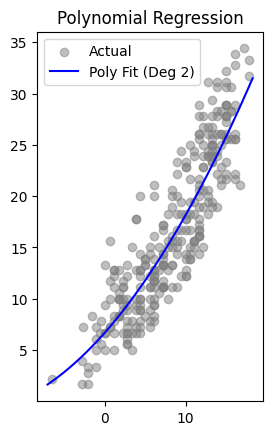

In [16]:
# Polynomial Plot
plt.subplot(1, 2, 2)
X_range = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_range_poly = poly_model.predict(poly_feat.transform(X_range))
plt.scatter(X_test_r, y_test_r, color='gray', alpha=0.5, label='Actual')
plt.plot(X_range, y_range_poly, color='blue', label='Poly Fit (Deg 2)')
plt.title('Polynomial Regression')
plt.legend()

plt.show()

In [17]:
# --- 2. Classification Data (Weather Type predict karna) ---
le = LabelEncoder()
df['weather_label'] = le.fit_transform(df['weather'])
X_cls = df[['precipitation', 'temp_max', 'temp_min', 'wind']]
y_cls = df['weather_label']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [18]:
# Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_c, y_train_c)
y_pred_log = log_model.predict(X_test_c)

In [19]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_c, y_train_c)
y_pred_knn = knn_model.predict(X_test_c)

In [20]:
# --- 3. Visualization ---
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [21]:
# --- 4. Comparison Results ---
print(f"Linear Regression R2 Score: {r2_score(y_test_r, y_pred_lin):.4f}")
print(f"Polynomial Regression R2 Score: {r2_score(y_test_r, poly_model.predict(X_test_poly)):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_c, y_pred_log):.4f}")
print(f"KNN Accuracy: {accuracy_score(y_test_c, y_pred_knn):.4f}")

Linear Regression R2 Score: 0.7750
Polynomial Regression R2 Score: 0.7933
Logistic Regression Accuracy: 0.8328
KNN Accuracy: 0.7782
